In [1]:
##############
## INITIATE ##
##############

## Imports
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import pickle
from PIL import Image
from torchvision import transforms
from sklearn.neighbors import KNeighborsClassifier

## Import modules
from f_wsi_reader import slide_path_to_tiles_at_coordinates
from f_wsi_reader import get_tile_map
from f_wsi_reader import get_tile_map_fast
from f_wsi_reader import read_slide
from f_wsi_reader import read_region
from f_wsi_reader import get_dimensions
from f_wsi_reader import apply_all_filters
from f_wsi_reader import apply_all_transforms
from f_wsi_reader import reassemble_tiles
from f_wsi_reader import select_patches_on_grid
from f_wsi_reader import get_tissue_mask
from f_extract_objects import extract_object_pixels
from f_extract_objects import polish
from f_extract_objects import inlay_objects
from f_extract_objects import get_bounding_box_square
from f_model_transformer import UNetTransformer as Model

#
###

In [2]:
#####################################
## FUNCTIONS FOR MODEL APPLICATION ##
#####################################

## numpy_to_device
## Goal:
## Format numpy array for model.
## Inputs:
## X (list of numpy arrays): Input array for the model (B, H, W, C).
## Outputs:
## tensors (list of torch tensors): Output tensor for model (B, C, H, W).
def numpy_to_device(X, tile_size, device):
    tensors = []
    for x in X:        
        x = cv2.resize(x, (tile_size, tile_size))
        x = torch.tensor(x)        
        x = x.swapaxes(2, 1).swapaxes(1, 0) # (H, W, C) --> (C, H, W)
        x = x.float()
        x = x[None, :, :, :] # (C, H, W) --> (B=1, C, H, W)
        x = x.to(device)
        tensors += [x]        
    return tensors

## device_to_numpy
## Goal: 
## Format tensor on device back to numpy array.
## Inputs:
## X (list of torch tensors): List of torch tensors predictions from the model (B, C, H, W).
## Outputs:
## images (list of numpy arrays): List of images produced by the model after re-formatting (B, H, W, C).
def device_to_numpy(X, tile_size):
    images = []
    for x in X:
        x = torch.sigmoid(x) * 255 # Logits to probabilities to [0, 255]
        x = x.cpu().numpy()
        x = x.swapaxes(0, 1).swapaxes(1, 2)    
        x = x.astype('uint8')
        x = cv2.resize(x, (tile_size, tile_size))
        x = np.argmax(x, axis=2).reshape(x.shape[0], x.shape[1], 1) # Only for multiple classes
        images += [x]        
    return images

#
###


In [3]:
###########
## PATHS ##
###########

## Paths TCGA FFPE
WSI_PATHS = [
    '/Users/user/Documents/projects/GlandSeg/data/TCGA_FFPEs/gdc_download_20241203_174927.283959/9f2c8275-5ff0-4167-9238-66effdd28e24/TCGA-HC-7213-01Z-00-DX1.5b03a3f2-ae77-4906-81b6-e9a5c0c5ed16.svs',
    # '/Users/user/Documents/projects/GlandSeg/data/TCGA_FFPEs/gdc_download_20241203_175041.015882/a7b9fe09-8614-4072-8534-5668beccbe60/TCGA-HC-A6AP-01Z-00-DX1.1E2C19B4-6757-488D-AFB4-71AE5FD6EC11.svs',
    # '/Users/user/Documents/projects/GlandSeg/data/TCGA_FFPEs/gdc_download_20241203_175115.987620/eb00cbed-63c4-4d47-9b6a-9dde1306b8cd/TCGA-KK-A7B2-01Z-00-DX1.3E779031-6FE4-4BD0-838C-D9ED49E1B9A7.svs',
    # '/Users/user/Documents/projects/GlandSeg/data/TCGA_FFPEs/gdc_download_20241203_175456.004065/f4323e88-33d7-4e7d-9763-b15be4e73b28/TCGA-XJ-A83F-01Z-00-DX1.11A9B6FC-16AB-44F2-B93E-7806693D90F7.svs',
]

#
###

In [4]:
################
## PARAMETERS ##
################

## Parameters for tile extraction
TILE_SIZE = 64 # Size of tiles for tissue extraction
FILTER_LOW = 10 # Low filter to remove black tiles
FILTER_HIGH = 240 # High filter to remove white tiles
FILTER_STD = 10 # Std filter to remove grey tiles

## Parameters for model application
LEVEL = 0 # Downsampling level 
TILE_SIZE_MODEL = 1024 # Size of tile for model
DEVICE = 'mps' # Device to load model, tiles, and perform computations
# PT_MODEL_IN = 'models/TransUNet_V2_0.pth' # Path to model weights
NUM_CLASSES = 3 # Number of outputs given by model
BATCH_SIZE = 32 # Maximum number of patches loaded at one time
DOWNSAMPLE_TILES = 4

## Parameters for gland extraction
DOWNSAMPLE_EXTRACTION = 4 # Downsample factor of mask for extraction of objects
NUM_POLISH = 1 # Number of times to erode mask (reduced clumped objects but may lose small objects)

## Parameters for storing glands
BUFFER = 128 # Added distance around bounding box (in pixels)
THRESHOLD_MIN = 1000 # Minimum surface area of objects (in pixels)
THRESHOLD_MAX = 40000000 # Maximum surface area of objects (in pixels)
PROP_BLACK = 0.0 # Maximum proportion of border pixels in image (proportion)
PT_OUTPUT_FOLDER = '/Users/user/Documents/projects/GlandSeg/outputs/V2_0_0_20250120/o1_extracted_glands/tcga_ffpes_debug' # Path where the gland images should be saved

#
###

In [107]:
"""
################
## LOAD MODEL ##
################

## Load model
print(f"Using {DEVICE} device")
model = Model(n_classes=NUM_CLASSES).to(DEVICE)
if os.path.exists(PT_MODEL_IN):
    model.load_state_dict(torch.load(PT_MODEL_IN))
    print("Loaded model")

#
###
"""

Using mps device
Loaded model


/var/folders/mf/6vvt1nwx5zz1gr1nj3hnqfzr0000gp/T/ipykernel_30432/183389046.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(PT_MODEL_IN))

In [5]:
#####################
## LOAD MODEL DUAL ##
#####################

## Model classes
from f_model import UNet
from f_model_transformer import UNetTransformer

## Load model
device = "mps"
print(f"Using {DEVICE} device")
pt_model_in = 'models/UNet_V1_1.pth'
model_1 = UNet(n_classes=NUM_CLASSES).to(device)
if os.path.exists(pt_model_in):
    model_1.load_state_dict(torch.load(pt_model_in))
    print("Loaded model")

## Load model
device = "mps"
print(f"Using {DEVICE} device")
pt_model_in = 'models/TransUNet_V1_1.pth'
model_2 = UNetTransformer(n_classes=NUM_CLASSES).to(device)
if os.path.exists(pt_model_in):
    model_2.load_state_dict(torch.load(pt_model_in))
    print("Loaded model")

## Combine models
def model(X):
    return model_1(X) + model_2(X)

#
###

Using mps device
Loaded model
Using mps device
Loaded model


/var/folders/mf/6vvt1nwx5zz1gr1nj3hnqfzr0000gp/T/ipykernel_13267/4080477768.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_1.load_state_dict(torch.load(pt_model_

In [6]:
##################################
## EXTRACT GLANDS AUTOMATICALLY ##
##################################

for WSI_PATH in WSI_PATHS:
    print(WSI_PATH)
    

/Users/user/Documents/projects/GlandSeg/data/TCGA_FFPEs/gdc_download_20241203_174927.283959/9f2c8275-5ff0-4167-9238-66effdd28e24/TCGA-HC-7213-01Z-00-DX1.5b03a3f2-ae77-4906-81b6-e9a5c0c5ed16.svs


In [7]:
##################
## GET TILE MAP ##
##################

## Open slide
slide = read_slide(WSI_PATH)
slide_size = get_dimensions(slide)

## Get tile_map
thumbnail, tile_map, canvas_size = get_tile_map_fast(slide, TILE_SIZE) # Canvas is a space containing the WSI.

## Rescale canvas size
canvas_size_ds = canvas_size // DOWNSAMPLE_TILES

#
###

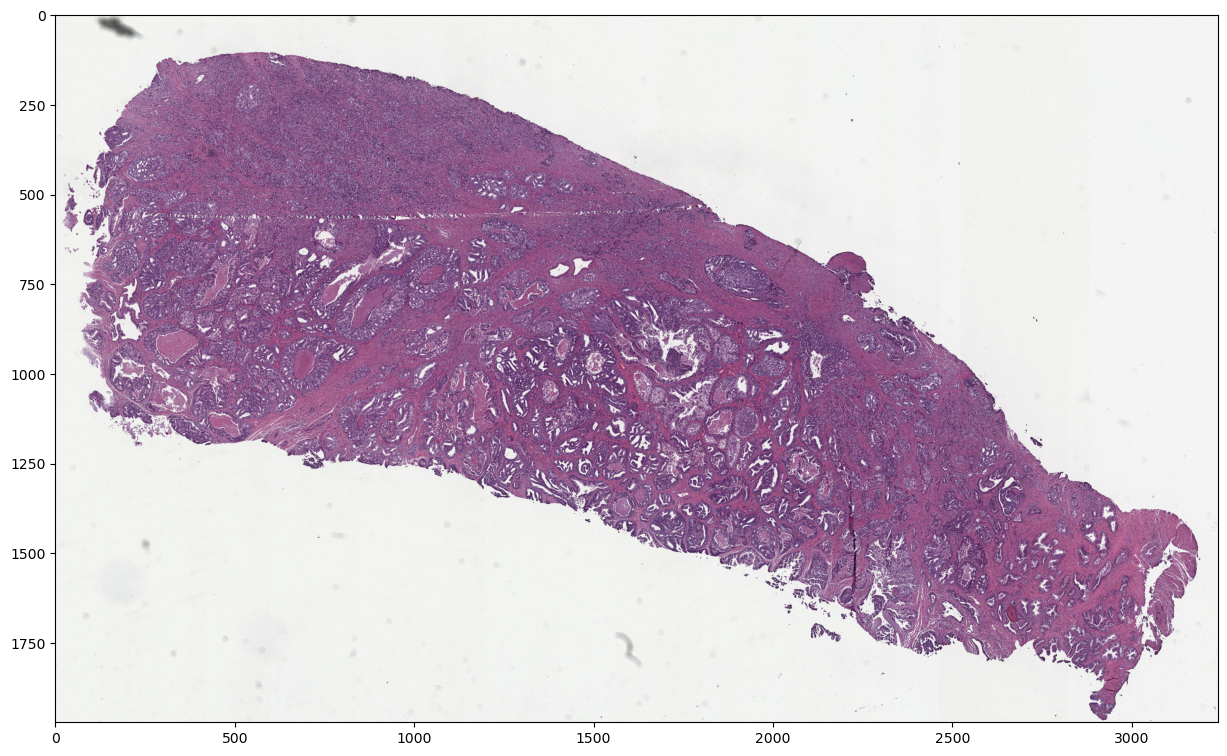

In [8]:
## Checks
plt.figure(figsize=(15,15))
plt.imshow(thumbnail)
plt.show()
plt.close()

In [9]:
##########################
## GET TILE COORDINATES ##
##########################

## Get tissue mask
tile_mask = get_tissue_mask(tile_map, FILTER_LOW, FILTER_STD, FILTER_HIGH, threshold=10000)

## Get coordinates of tiles with tissue
tile_coordinates = (np.argwhere(tile_mask[:,:,0] > 0) * TILE_SIZE).astype(int)
tile_coordinates = [[tile_coordinate[0], tile_coordinate[1]] for tile_coordinate in tile_coordinates] # (x: H, y: W)

#
###

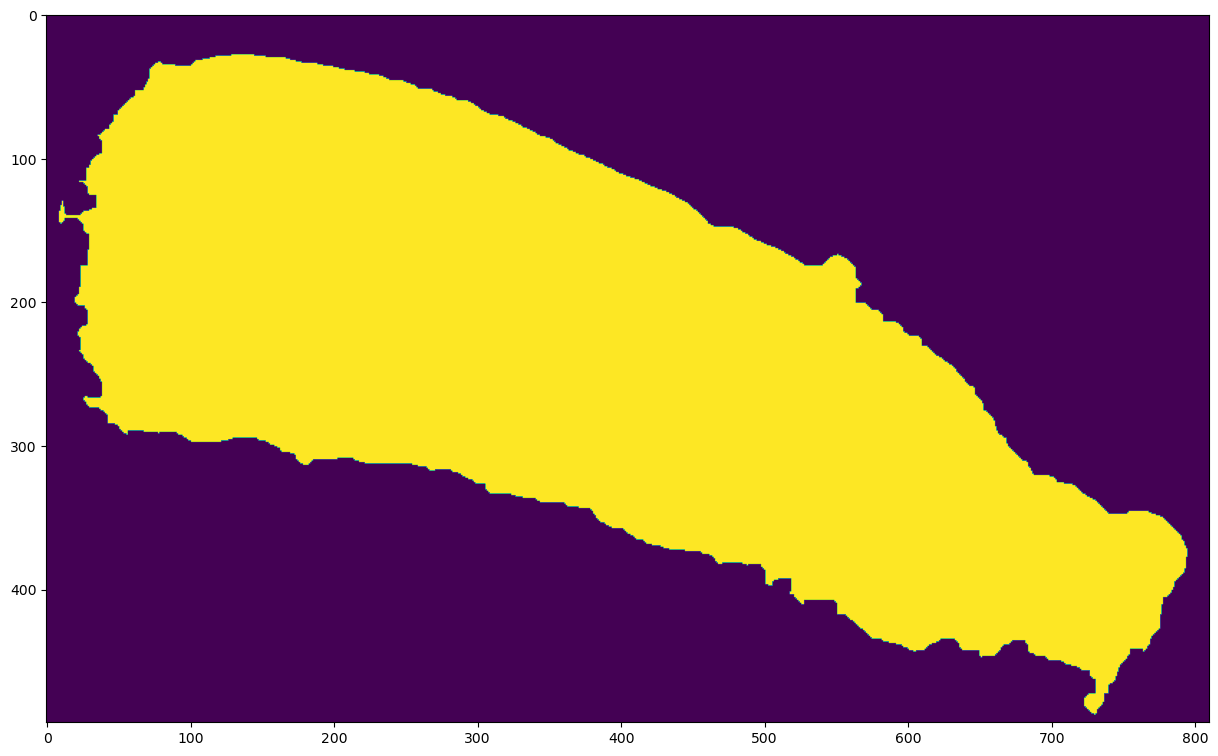

In [10]:
## Checks
plt.figure(figsize=(15,15))
plt.imshow(tile_mask)
plt.show()
plt.close()

In [11]:
###############################
## EXTRACT PATCHES FOR MODEL ##
###############################

## Remove patches too close to the edges (WIP TO REMOVE)
tile_coordinates_thinned = []
for tile_coordinates_ in tile_coordinates:
    coords_0_lo = tile_coordinates_[0] + int(TILE_SIZE/2) - int(TILE_SIZE_MODEL/2)
    coords_0_hi = tile_coordinates_[0] + int(TILE_SIZE/2) + int(TILE_SIZE_MODEL/2)
    coords_1_lo = tile_coordinates_[1] + int(TILE_SIZE/2) - int(TILE_SIZE_MODEL/2)
    coords_1_hi = tile_coordinates_[1] + int(TILE_SIZE/2) + int(TILE_SIZE_MODEL/2)
    if (coords_0_lo > 0) & (coords_0_hi < canvas_size[0]) & (coords_1_lo > 0) & (coords_1_hi < canvas_size[1]):
        tile_coordinates_thinned += [[coords_0_lo, coords_1_lo]]

## Get patches closest to grid points (WIP TO MAKE FASTER)
tile_coordinates_thinned = select_patches_on_grid(tile_coordinates_thinned, grid_spacing=512)
print(f'Number of patches: {len(tile_coordinates_thinned)}')

## Rescale coordinates according to downsampling factor
tile_coordinates_thinned_downsampled = [[coords[0] // DOWNSAMPLE_TILES, coords[1] // DOWNSAMPLE_TILES] for coords in tile_coordinates_thinned]

#
###

Number of patches: 3044


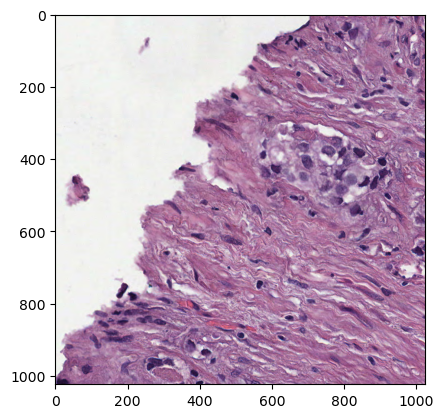

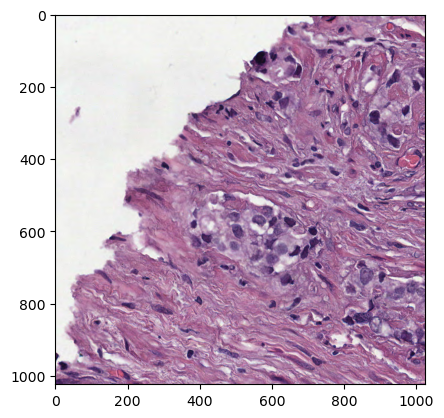

In [12]:
## Checks
for i in range(0, len(tile_coordinates_thinned), BATCH_SIZE):
    
    ## Load patches batch
    tile_coordinates_thinned_ = tile_coordinates_thinned[i:i + BATCH_SIZE]
    patches_ = slide_path_to_tiles_at_coordinates(WSI_PATH, tile_coordinates_thinned_, TILE_SIZE_MODEL, LEVEL)
    plt.imshow(patches_[0])
    plt.show()
    plt.imshow(patches_[1])
    plt.show()
    break

In [ ]:
################# 
## APPLY MODEL ##
#################

## Apply to all tiles
patches = []
preds = []
for i in range(0, len(tile_coordinates_thinned), BATCH_SIZE):
    
    ## Load patches batch
    tile_coordinates_thinned_ = tile_coordinates_thinned[i:i + BATCH_SIZE]
    patches_ = slide_path_to_tiles_at_coordinates(WSI_PATH, tile_coordinates_thinned_, TILE_SIZE_MODEL, LEVEL)

    ## Apply model
    X = numpy_to_device(patches_, TILE_SIZE_MODEL, DEVICE)
    with torch.no_grad():
        for x in X:                
            preds_ = model(x)        
            preds_ = device_to_numpy(preds_, TILE_SIZE_MODEL // DOWNSAMPLE_TILES)[0] # WiP: Only for single patch            
            preds += [preds_] # WiP: Only for single patch

    ## Reassemble downsampled WSI
    for patches__ in patches_:
        patches__ = cv2.resize(patches__, (TILE_SIZE_MODEL // DOWNSAMPLE_TILES, TILE_SIZE_MODEL // DOWNSAMPLE_TILES))
        patches += [patches__]

#
###

In [14]:
####################
## REASSEMBLE WSI ##
####################

## Reassemble image
img = reassemble_tiles(patches, tile_coordinates_thinned_downsampled, canvas_size_ds[0], canvas_size_ds[1])

## Compute slide-level tissue mask
tissue_mask = cv2.resize(tile_mask, (canvas_size_ds[1], canvas_size_ds[0]), cv2.INTER_LINEAR)[:,:,None] # (H, W)

## Mask WSI
img = img * tissue_mask

#
###

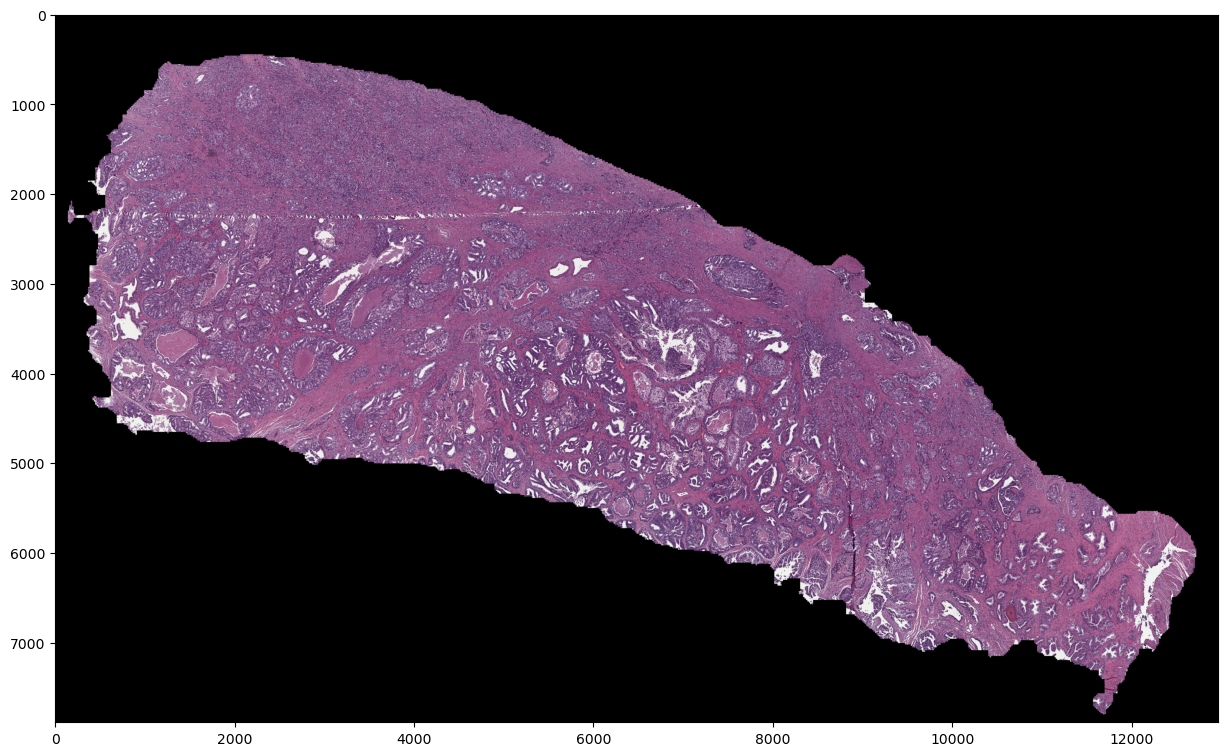

In [15]:
## Checks
plt.figure(figsize=(15,15))
plt.imshow(img)
plt.show()
plt.close()

In [22]:
############################
## REASSEMBLE PREDICTIONS ##
############################

## Assemble predictions
mask = reassemble_tiles(preds, tile_coordinates_thinned_downsampled, canvas_size_ds[0], canvas_size_ds[1])
mask = mask[:,:,0].reshape(mask.shape[0], mask.shape[1], 1) * tissue_mask

## Keep full size mask
mask_full_size = mask

#
###

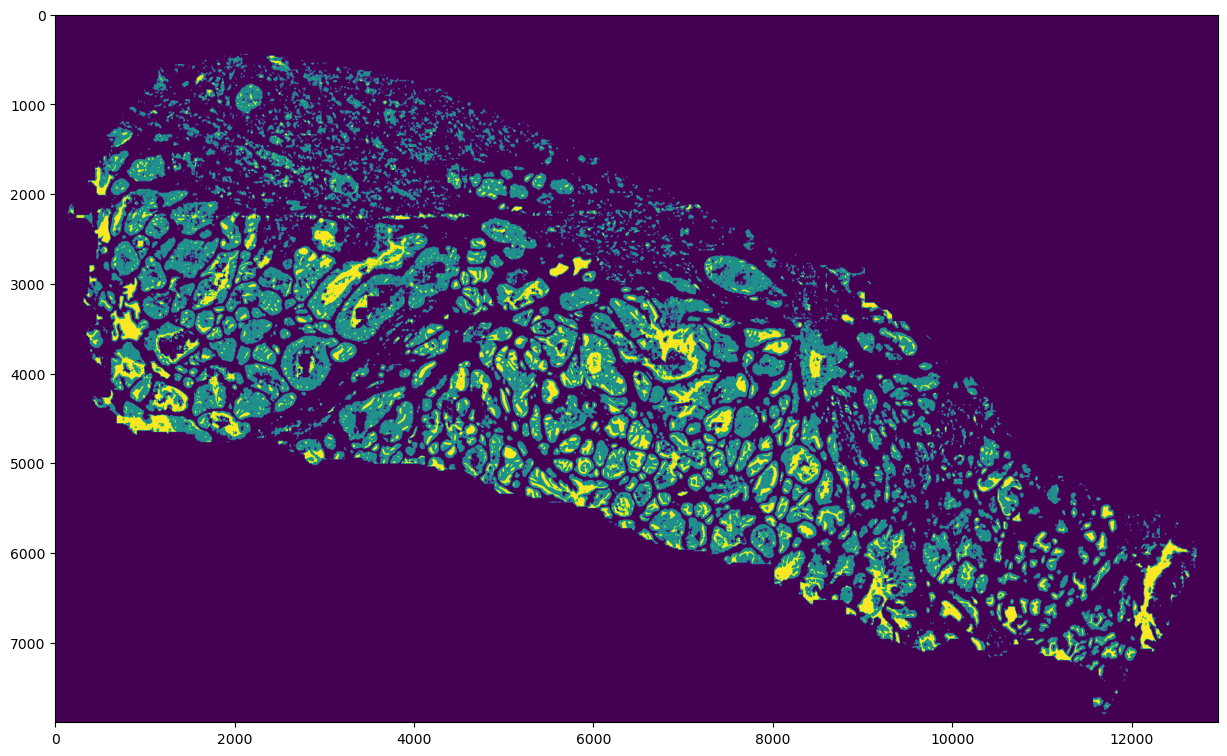

In [19]:
## Checks
plt.figure(figsize=(15,15))
plt.imshow(mask)
plt.show()
plt.close()

In [23]:
########################################
## PREPARE MASK FOR OBJECT EXTRACTION ##
########################################

## Binarise mask
mask = ((mask > 0.5)*1).astype('uint8')
mask = cv2.resize(mask, (mask.shape[1] // DOWNSAMPLE_EXTRACTION, mask.shape[0] // DOWNSAMPLE_EXTRACTION))
mask = mask[:,:,None]

## Polish mask
for i in range(NUM_POLISH):
    mask = polish(mask)
    mask = mask[:,:,None]

## Downscale tissue mask
tissue_mask_downsampled = cv2.resize(tissue_mask, (tissue_mask.shape[1] // DOWNSAMPLE_EXTRACTION, tissue_mask.shape[0] // DOWNSAMPLE_EXTRACTION))
tissue_mask_downsampled = tissue_mask_downsampled[:,:,None]

#
###

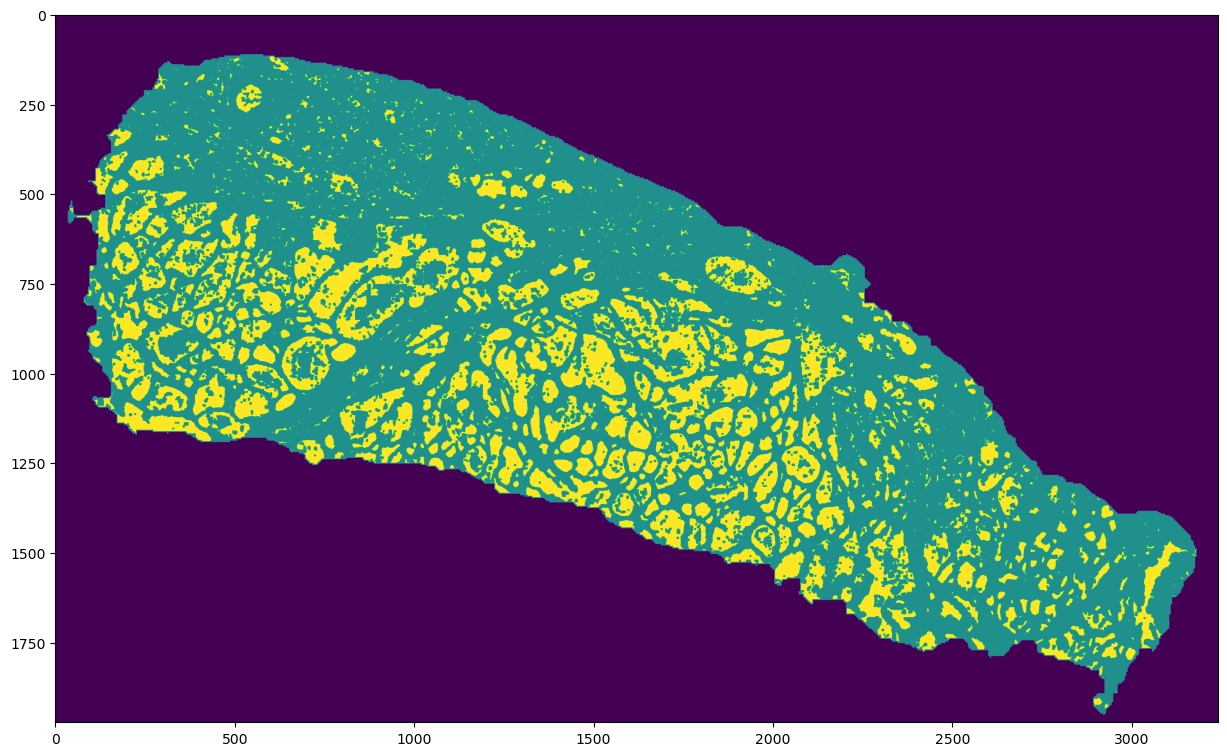

In [24]:
## Checks
plt.figure(figsize=(15,15))
plt.imshow(mask + tissue_mask_downsampled)
plt.show()
plt.close()

In [25]:
#####################
## EXTRACT OBJECTS ##
#####################

## Get objects
gland_coords = extract_object_pixels(mask)
print(f'Number of glands: {len(gland_coords)}')

#
###

Number of glands: 1765


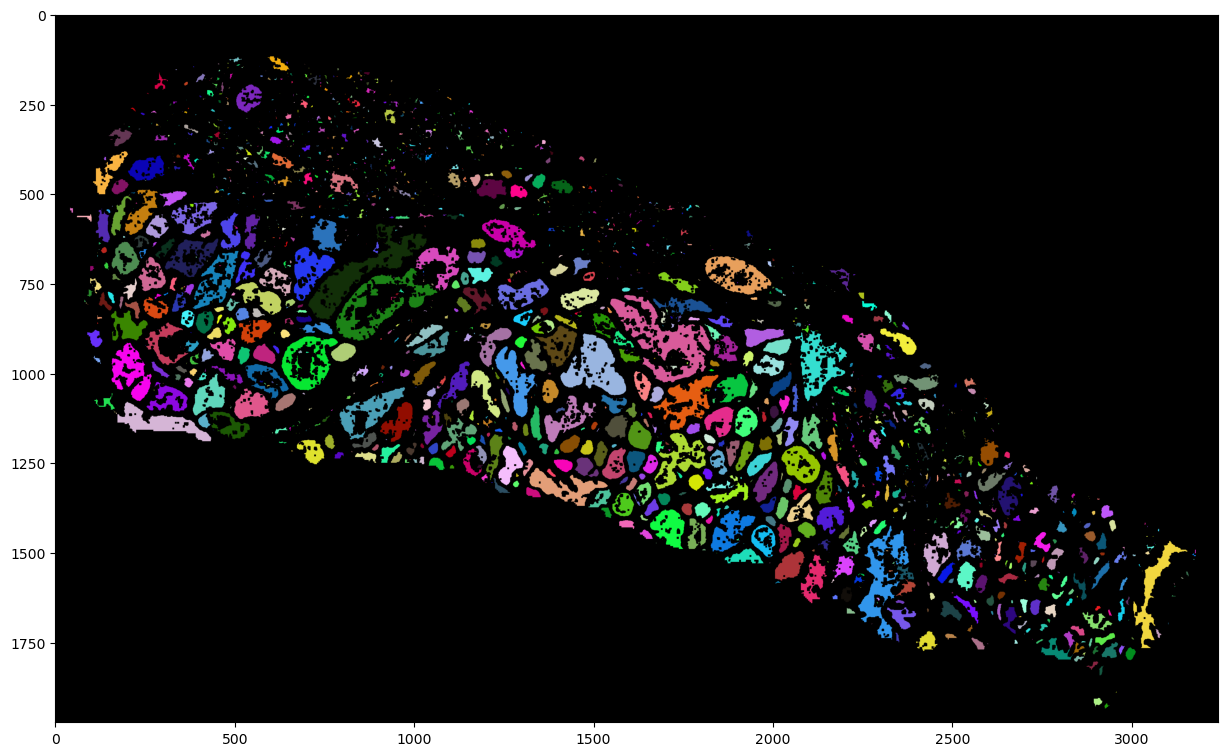

In [26]:
## Checks
fig, axes = plt.subplots(1, 1, figsize=(15,15))
axes.imshow(inlay_objects(mask, gland_coords))
plt.show()
plt.close()

In [27]:
####################
## FILTER OBJECTS ##
####################

## Criteria for filtering
buffer = BUFFER // DOWNSAMPLE_EXTRACTION # Added distance around bounding box (in pixels)
threshold_min = THRESHOLD_MIN // (DOWNSAMPLE_EXTRACTION ** 2) // (DOWNSAMPLE_TILES ** 2) # Minimum surface area of objects (in pixels)
threshold_max = THRESHOLD_MAX // (DOWNSAMPLE_EXTRACTION ** 2) // (DOWNSAMPLE_TILES ** 2) # Maximum surface area of objects (in pixels)

## Extract and save each object
gland_coords_thinned = []
for i, coords in enumerate(gland_coords):

    ## Discard small objects
    if (len(coords) > threshold_min) & (len(coords) < threshold_max):
        
        ## Get bounding box of the object
        x_min, y_min, x_max, y_max = get_bounding_box_square(gland_coords[i])

        ## Get object
        object_img = mask[(x_min - buffer):(x_max + buffer), (y_min - buffer):(y_max + buffer)]
        object_tissue = tissue_mask_downsampled[(x_min - buffer):(x_max + buffer), (y_min - buffer):(y_max + buffer)]
        
        ## Check size
        if (object_img.shape[0] > 0) & (object_img.shape[1] > 0):
            
            if object_tissue.sum()/(object_tissue.shape[0] * object_tissue.shape[1]) >= (1 - PROP_BLACK):                    
        
                ## Save the object coordinates
                gland_coords_thinned += [gland_coords[i]]

## Check final number of glands
print(f'Final number of glands: {len(gland_coords_thinned)}')

## Rescale coordinates to original size
rescaled_gland_coords = [coords * DOWNSAMPLE_EXTRACTION * DOWNSAMPLE_TILES for coords in gland_coords_thinned]

#
###

Final number of glands: 1120


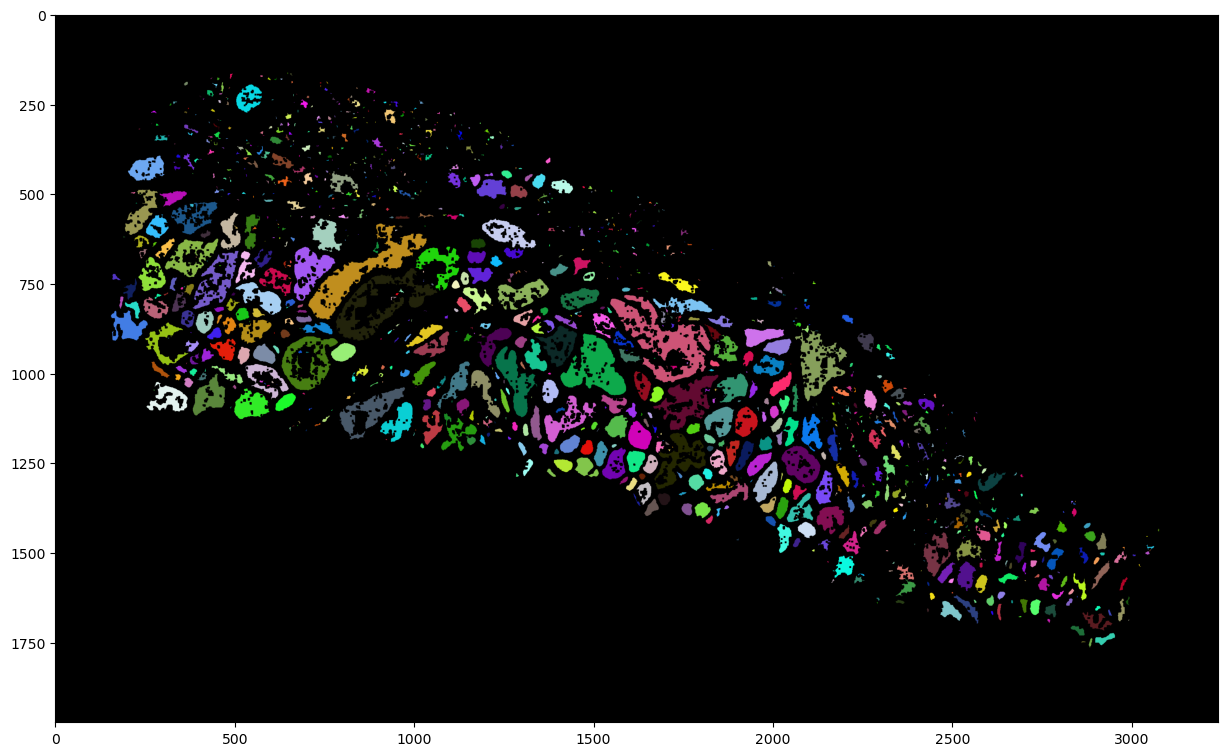

In [29]:
## Checks
fig, axes = plt.subplots(1, 1, figsize=(15,15))
axes.imshow(inlay_objects(mask, gland_coords_thinned))
plt.show()
plt.close()

In [38]:
##################
## SAVE OBJECTS ##
##################

## Paths
os.makedirs(PT_OUTPUT_FOLDER, exist_ok=True)

## Extract and save each object
bbox_list = []
cluster_labels = []
for i, coords in enumerate(rescaled_gland_coords):
        
    ## Get bounding box of the object
    x_min, y_min, x_max, y_max = get_bounding_box_square(coords)

    ## Get object
    location_xy = (x_min - BUFFER, y_min - BUFFER)
    tile_size_xy = (x_max - x_min + 2 * BUFFER, y_max - y_min + 2 * BUFFER)
    object_img = read_region(slide, location_xy, LEVEL, tile_size_xy)
    object_img = cv2.cvtColor(object_img, cv2.COLOR_BGR2RGB)

    ## Save the object image    
    object_filename = os.path.join(PT_OUTPUT_FOLDER, f'{os.path.basename(WSI_PATH)}__{x_min}_{x_max}_{y_min}_{y_max}.png')
    cv2.imwrite(object_filename, object_img)

    ## Get mask
    # location_xy = (x_min - BUFFER, y_min - BUFFER) // DOWNSAMPLE_TILES
    # tile_size_xy = (x_max - x_min + 2 * BUFFER, y_max - y_min + 2 * BUFFER)
    object_mask = mask_full_size[(x_min - BUFFER)// DOWNSAMPLE_TILES:(x_max + BUFFER)// DOWNSAMPLE_TILES, (y_min - BUFFER) // DOWNSAMPLE_TILES:(y_max + BUFFER) // DOWNSAMPLE_TILES]
    object_mask = cv2.resize(object_mask, (object_mask.shape[1] * DOWNSAMPLE_TILES, object_mask.shape[0] * DOWNSAMPLE_TILES), cv2.INTER_CUBIC )[:,:,None]
    object_mask = cv2.cvtColor(object_mask, cv2.COLOR_BGR2RGB)
    object_mask[:,:,0] = ((object_mask[:,:,0] == 0) * 255).astype(np.uint8)
    object_mask[:,:,1] = ((object_mask[:,:,1] == 1) * 255).astype(np.uint8)
    object_mask[:,:,2] = ((object_mask[:,:,2] == 2) * 255).astype(np.uint8)
    
    ## Save mask
    object_filename = os.path.join(PT_OUTPUT_FOLDER, f'{os.path.basename(WSI_PATH)}__{x_min}_{x_max}_{y_min}_{y_max}_mask.png')
    cv2.imwrite(object_filename, object_mask)

    ## Save bbox
    bbox_list += [[x_min, y_min, x_max, y_max]]

## Save bbox
bbox_filename = os.path.join(PT_OUTPUT_FOLDER, f'{os.path.basename(WSI_PATH)}_bboxes.png')
np.save(bbox_filename, bbox_list)
    
#
###

In [28]:
###############
## FUNCTIONS ##
###############

def load_encoder(encoder_path, device='cpu'):
    """
    Loads a pre-trained ResNet18 encoder.

    Args:
        encoder_path (str): Path to the saved encoder weights.
        device (str): Device to load the encoder onto ('cpu' or 'cuda').

    Returns:
        torch.nn.Module: The loaded ResNet18 encoder.
    """
    from torchvision.models import resnet18
    
    # Define the encoder class (ResNet18 without classification layer)
    class ResNet18Encoder(torch.nn.Module):
        def __init__(self):
            super(ResNet18Encoder, self).__init__()
            self.resnet18 = resnet18(pretrained=True)
            self.resnet18 = torch.nn.Sequential(*list(self.resnet18.children())[:-1])  # Remove the FC layer
            self.flatten = torch.nn.Flatten()

        def forward(self, x):
            x = self.resnet18(x)
            x = self.flatten(x)
            return x
    
    # Initialize and load the encoder
    encoder = ResNet18Encoder()
    encoder.load_state_dict(torch.load(encoder_path, map_location=device))
    encoder.to(device)
    encoder.eval()  # Set to evaluation mode
    return encoder

def load_knn_classifier(knn_model_path):
    """
    Loads the pre-trained k-NN classifier from a file.

    Args:
        knn_model_path (str): Path to the saved k-NN classifier file.

    Returns:
        KNeighborsClassifier: The loaded k-NN classifier.
    """
    with open(knn_model_path, 'rb') as f:
        knn_classifier = pickle.load(f)
    return knn_classifier

def encode_image(image, encoder):
    """
    Encodes an image into its high-dimensional embedding using the pre-trained encoder.
    
    Args:
        image (np.array): Image.
        encoder (torch.nn.Module): Pre-trained ResNet18 encoder.        
    
    Returns:
        torch.Tensor: The high-dimensional embedding of the image.
    """
    ## Preprocess the image    
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    ## Apply preprocessing: CLAHE, resize, normalization
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    image = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(image)
    l = clahe.apply(l)
    image = cv2.merge((l, a, b))
    image = cv2.cvtColor(image, cv2.COLOR_LAB2RGB)
    image = cv2.resize(image, (224, 224))

    ## Convert image to PIL format for transforms
    image = Image.fromarray(image)

    ## Define the same transformation pipeline used during training
    transform = transforms.Compose([    
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    ## Transformations
    image = transform(image)  # Apply the same transformation pipeline used during training

    ## Add a batch dimension (for a single image)
    image = image.unsqueeze(0)

    ## Ensure the encoder is in evaluation mode
    encoder.eval()

    ## Generate the embedding
    with torch.no_grad():  # Disable gradients for inference
        embedding = encoder(image)

    return embedding

def predict_cluster(image_embedding, knn_classifier):
    """
    Predicts the cluster for a given image embedding using the pre-trained k-NN classifier.
    
    Args:
        image_embedding (torch.Tensor): The embedding of the image.
        knn_classifier (sklearn.neighbors.KNeighborsClassifier): Pre-trained k-NN classifier.
    
    Returns:
        int: The predicted cluster label.
    """
    ## Convert the embedding to a NumPy array (k-NN expects NumPy input)
    image_embedding_np = image_embedding.cpu().numpy()

    ## Predict the cluster using k-NN
    predicted_cluster = knn_classifier.predict(image_embedding_np)

    return predicted_cluster[0]  # Return the predicted cluster label
    
#
###

In [127]:
#########################
## INITIATE CLASSIFIER ##
#########################

## Paths to the pre-trained encoder and k-NN classifier
encoder_path = '/Users/user/Documents/GitHub/GlandSeg/scripts/b2_0_0/p_classify_glands/scripts/V0_0_0/model_TCGA_V0_3.pth'
knn_model_path = '/Users/user/Documents/GitHub/GlandSeg/scripts/b2_0_0/p_classify_glands/scripts/V0_0_0/knn_classifier.pkl'

## Device setup
device = 'cpu'  # or 'cuda' if GPU is available

## Load the pre-trained ResNet18 encoder
encoder = load_encoder(encoder_path, device=device)

## Load the pre-trained k-NN classifier
knn_classifier = load_knn_classifier(knn_model_path)

#
###

/opt/anaconda3/envs/pytorch/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/pytorch/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/var/folders/mf/6vvt1nwx5zz1gr1nj3hnqfzr0000gp/T/ipykernel_30432/1170733761.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://g

In [128]:
##################
## SAVE OBJECTS ##
##################

## Paths
os.makedirs(PT_OUTPUT_FOLDER, exist_ok=True)

## Extract and save each object
bbox_list = []
cluster_labels = []
for i, coords in enumerate(rescaled_gland_coords):
        
    ## Get bounding box of the object
    x_min, y_min, x_max, y_max = get_bounding_box_square(coords)

    ## Get object
    location_xy = (x_min - BUFFER, y_min - BUFFER)
    tile_size_xy = (x_max - x_min + 2 * BUFFER, y_max - y_min + 2 * BUFFER)
    object_img = read_region(slide, location_xy, LEVEL, tile_size_xy)
    object_img = cv2.cvtColor(object_img, cv2.COLOR_BGR2RGB)
       
    ## Save the object image    
    object_filename = os.path.join(PT_OUTPUT_FOLDER, f'{os.path.basename(WSI_PATH)}__{x_min}_{x_max}_{y_min}_{y_max}.png')
    cv2.imwrite(object_filename, object_img)

    ## Encode the new image to obtain its embedding
    image_embedding = encode_image(object_img, encoder)
    
    ## Predict the cluster for the new image using the k-NN classifier
    predicted_cluster = predict_cluster(image_embedding, knn_classifier)
    # print(f'The predicted cluster for the image is: {predicted_cluster}')

    ## Collect
    cluster_labels += [predicted_cluster]    

    ## Save bbox
    bbox_list += [[x_min, y_min, x_max, y_max]]

## Save bbox
bbox_filename = os.path.join(PT_OUTPUT_FOLDER, f'{os.path.basename(WSI_PATH)}_bboxes.png')
np.save(bbox_filename, bbox_list)
    
#
###

In [129]:
## inlay_objects
## Goal:
## Visualise individual objects in an image.
## Inputs:
## img (numpy array): Image as a numpy array.
## coordinates (list): List of coordinates of pixels of objects.
## color_index_list (list): List of index of colour (e.g. cluster index).
## Outputs:
## img (numpy array): Image with objects inlaid in different colors.
def inlay_objects(img, coordinates, color_index_list=[], black_canvas=True):
    if color_index_list != []:
        num_unique_colors = np.max(color_index_list) + 1        
        color_vect = [np.random.uniform(0, 1, 3) * 255 for _ in range(num_unique_colors)]        
    if black_canvas == True:
        img = img * 0
    else:
        img = img // 2
    if len(img.shape) < 3:
        img = img[:, :, None]
    if img.shape[2] == 1: 
        img = np.repeat(img, 3, axis=2)
    for i in range(len(coordinates)):
        coordinates_i = coordinates[i].astype("int")
        if color_index_list != []:            
            color_vect_ = color_vect[color_index_list[i]]            
        else:
            color_vect_ = np.random.uniform(0, 1, 3) * 255
        img[coordinates_i[:, 0], coordinates_i[:, 1], 0] = color_vect_[0]
        img[coordinates_i[:, 0], coordinates_i[:, 1], 1] = color_vect_[1]
        img[coordinates_i[:, 0], coordinates_i[:, 1], 2] = color_vect_[2]
    return img


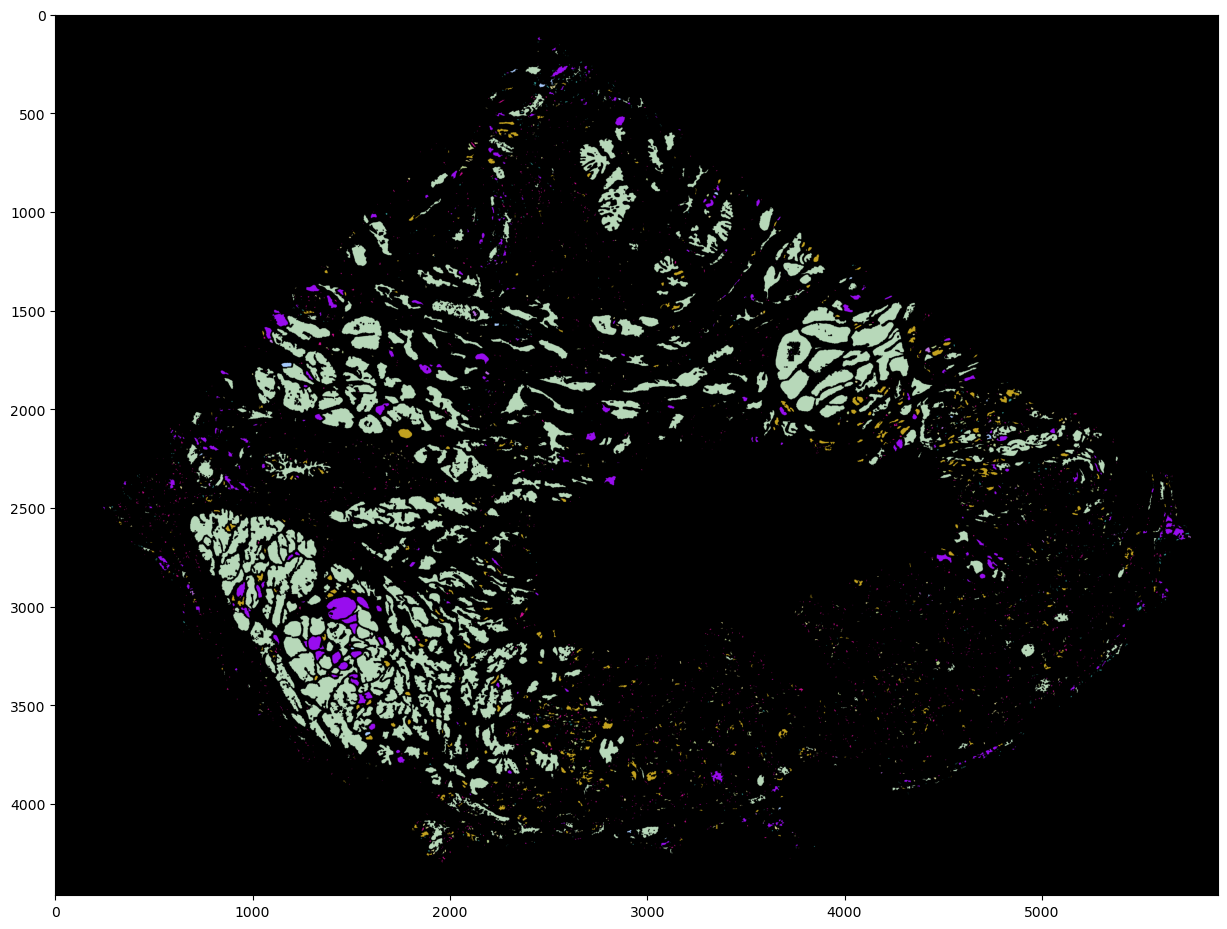

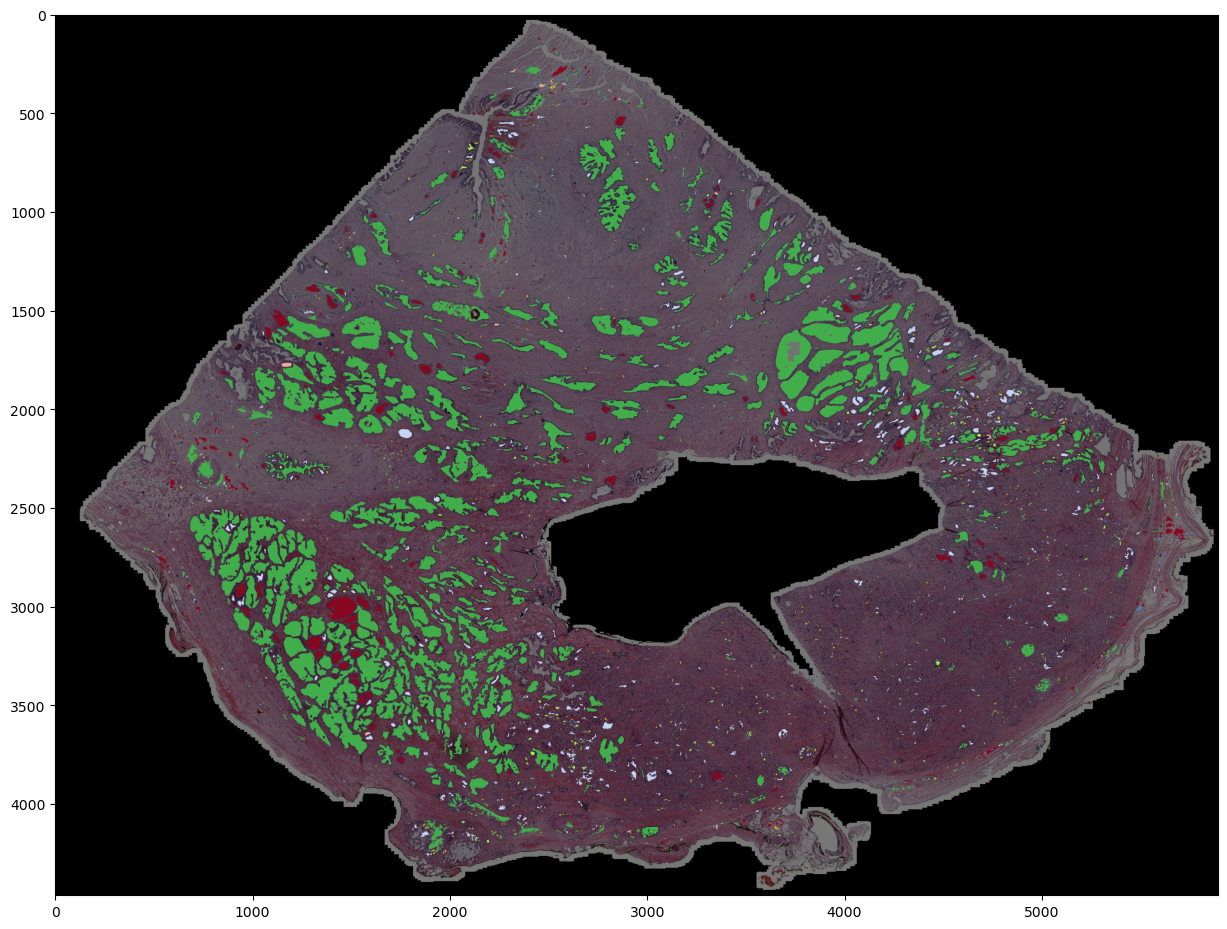

In [130]:
## Checks
fig, axes = plt.subplots(1, 1, figsize=(15,15))
axes.imshow(inlay_objects(mask, gland_coords_thinned, cluster_labels))
plt.show()
plt.close()

## Reassemble image
img = reassemble_tiles(patches, tile_coordinates_thinned_downsampled, canvas_size_ds[0], canvas_size_ds[1])
img = cv2.resize(img, (mask.shape[1], mask.shape[0]))
fig, axes = plt.subplots(1, 1, figsize=(15,15))
axes.imshow(inlay_objects(img, gland_coords_thinned, cluster_labels, False))
plt.show()
plt.close()



In [131]:
#
###